## Sample hash parameters from random.org

Use to get new hash function parameters:
- ``array_a``
- ``array_a'``
- ``array_b'``
- ``array_a0123``

### ``array_a``

In [ ]:
import requests

def get_random_64bit_odd_numbers(n: int):
    total_bits = n * 64
    nbytes = (total_bits + 7) // 8
    URL = f"https://www.random.org/cgi-bin/randbyte?nbytes={nbytes}&format=b"

    resp = requests.get(URL)
    resp.raise_for_status()

    bitstring = resp.text.strip().replace("\n", "").replace(" ", "")
    bitstring = bitstring[:total_bits]

    blocks = []
    for i in range(0, total_bits, 64):
        chunk = bitstring[i:i+64]
        x = int(chunk, 2)
        x |= 1
        blocks.append(x)

    return blocks


def format_1d_list_as_UL(xs):
    body = ";".join(f"{x}UL" for x in xs)
    return f"[|{body}|]"


### prints : array_a
n = 5
vals = get_random_64bit_odd_numbers(n)
print(format_1d_list_as_UL(vals))

[|12319222750146864419UL;16114691301978176249UL;3791869857334564063UL;8004454817599031957UL;14173630440495860669UL|]


### ``array_a'`` & ``array_b'``

In [ ]:
import requests

def get_random_89bit_numbers(n: int):
    total_bits = n * 89

    URL = f"https://www.random.org/cgi-bin/randbyte?nbytes={(total_bits+7)//8}&format=b"
    resp = requests.get(URL)
    resp.raise_for_status()

    bitstring = resp.text.strip().replace("\n", "").replace(" ", "")

    bitstring = bitstring[:total_bits] # trim to number of bits needed

    # split into blocks of 89 bits
    blocks = [
        int(bitstring[i:i+89], 2)
        for i in range(0, total_bits, 89)
    ]

    return blocks


def format_1d_list_as_I(xs):
    body = ";".join(f"{x}I" for x in xs)
    return f"[|{body}|]"


### prints : array_a'
n = 5
vals = get_random_89bit_numbers(n)
print(format_1d_list_as_I(vals))

### prints : array_b'
n = 5
vals = get_random_89bit_numbers(n)
print(format_1d_list_as_I(vals))


[|94528161750754160904630463I;475143385504045005455374079I;189288392420571259358108365I;376735684152147520879667925I;343105826237677516762807280I|]
[|311389585415385458547374816I;115300290968116515714577533I;513854028619251797804563447I;104944534831667168476721225I;608473273272629634216742673I|]


### ``array_a0123``

In [ ]:
import requests
import numpy as np

URL = "https://www.random.org/cgi-bin/randbyte?nbytes=4450&format=b"

resp = requests.get(URL)
resp.raise_for_status()
bitstring = resp.text.strip().replace("\n", "").replace(" ", "")

N_BITS = 89 * 4 * 100
assert len(bitstring) == N_BITS, f"Fik {len(bitstring)} bits, forventede {N_BITS}"

# split into blocks of 89 bits
block_size = 89
blocks = [
    int(bitstring[i:i + block_size], 2)
    for i in range(0, N_BITS, block_size)
]

arr = np.array(blocks, dtype=str).reshape(100, 4)

def format_array(a: np.ndarray) -> str:
    rows = []
    for row in a:
        elems = ";".join(f"{x}I" for x in row)
        rows.append(f"[|{elems}|]")
    return "[|" + ";".join(rows) + "|]"


### prints : array_a0123
print(format_array(arr))

[|[|320443549933039664387189310I;107230393983233012641512292I;211934704094934825136433351I;26484873745933809810425094I|];[|340773580066423632575466061I;348270562867865964490118410I;110688533714776116377585960I;176753103851924989717499449I|];[|459508589771856708050228512I;172048620436921987857860033I;543303313775733482350801373I;303276047529572088033561813I|];[|131739131628559233850786373I;50926678129945613466050526I;69113641481444776893267593I;602494424497362251198835803I|];[|108839279510277958816610965I;276143826130185241547022816I;473041023287041310016981707I;177651378047111363061076488I|];[|529358343020159527292599987I;332765469966125172281964565I;190411086354140303039653520I;249797805552632886863192757I|];[|354935051804075875824611635I;532339544286473027244541644I;87500303435847969241552381I;520080086921088761834120157I|];[|223868473314300892787195109I;237396202418756967880669496I;550201491049023232905008632I;520714338483272441042150974I|];[|259762088601657201507442015I;13470378900

## Program output formating and plotting

In [18]:
import json5

with open("Project/test.json", "r", encoding="utf-16") as f:
    data = json5.load(f)

data

{'Opgave_1': {'runtime_ms': {'mulshift': 300.74, 'mulmodprime': 4477.16},
  'debug_sums': {'mulshift': 274877229056, 'mulmodprime': 274869569024}},
 'Opgave_3': [{'l': 10,
   'runtime_ms': {'mulshift': 849.993, 'mulmodprime': 5151.577},
   'debug_sums': {'mulshift': 152709989260, 'mulmodprime': 152709989260}},
  {'l': 11,
   'runtime_ms': {'mulshift': 833.819, 'mulmodprime': 5325.175},
   'debug_sums': {'mulshift': 76355001460, 'mulmodprime': 76355001460}},
  {'l': 12,
   'runtime_ms': {'mulshift': 866.419, 'mulmodprime': 5500.642},
   'debug_sums': {'mulshift': 38177514380, 'mulmodprime': 38177514380}},
  {'l': 13,
   'runtime_ms': {'mulshift': 939.505, 'mulmodprime': 5672.41},
   'debug_sums': {'mulshift': 19088784500, 'mulmodprime': 19088784500}},
  {'l': 14,
   'runtime_ms': {'mulshift': 1101.021, 'mulmodprime': 6038.898},
   'debug_sums': {'mulshift': 9544446860, 'mulmodprime': 9544446860}},
  {'l': 15,
   'runtime_ms': {'mulshift': 1340.035, 'mulmodprime': 7256.619},
   'debug_su

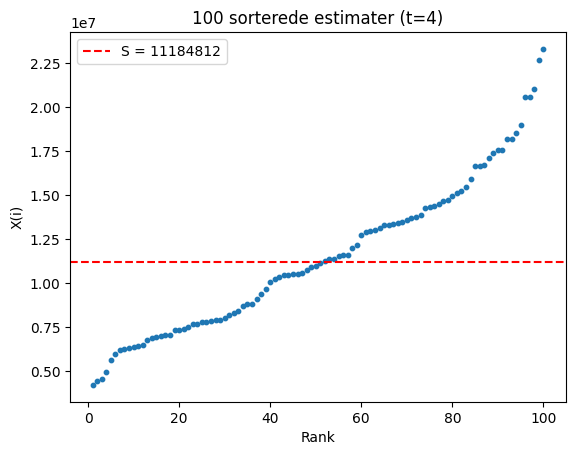

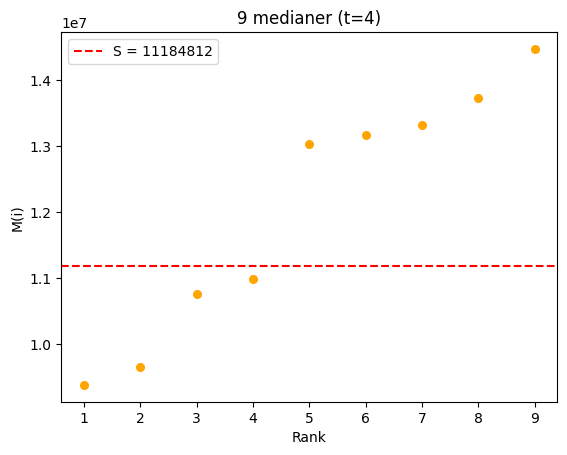

In [19]:
import matplotlib.pyplot as plt

S = data["Opgave_7_8"][0]["square_sum"]
entry = data["Opgave_7_8"][0]

# GRAF 1: 100 sorterede estimater
points = entry["estimates"]
xs = [p["x"] for p in points]
ys = [p["y"] for p in points]
plt.figure()
plt.scatter(xs, ys, s=10)
plt.axhline(y=S, color="red", linestyle="--", label=f"S = {S}")
plt.xlabel("Rank")
plt.ylabel("X(i)")
plt.title(f"100 sorterede estimater (t={entry['t']})")
plt.legend()
plt.savefig("opgave7_estimates.png")
plt.show()

# GRAF 2: 9 medianer
medians = entry["median_estimates"]
mxs = [p["x"] for p in medians]
mys = [p["y"] for p in medians]
plt.figure()
plt.scatter(mxs, mys, s=30, color="orange")
plt.axhline(y=S, color="red", linestyle="--", label=f"S = {S}")
plt.xlabel("Rank")
plt.ylabel("M(i)")
plt.title(f"9 medianer (t={entry['t']})")
plt.legend()
plt.savefig("opgave7_medians.png")
plt.show()

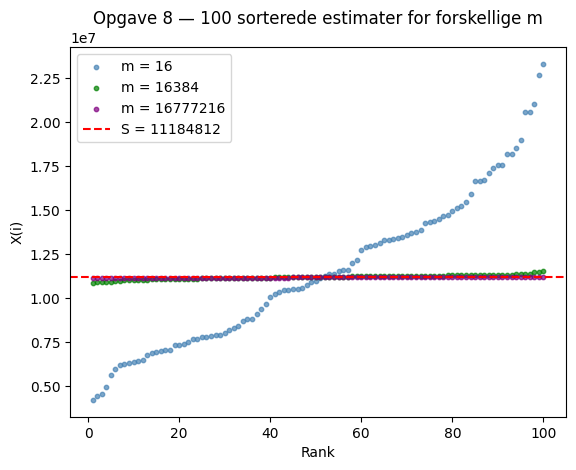

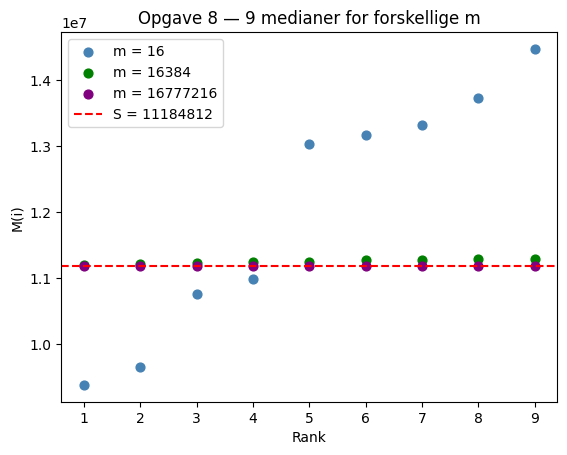

In [20]:
colors = ["steelblue", "green", "purple"]
entries = data["Opgave_7_8"]
S = entries[0]["square_sum"]

# GRAF 3: 100 sorterede estimater for alle m
plt.figure()
for i, entry in enumerate(entries):
    xs = [p["x"] for p in entry["estimates"]]
    ys = [p["y"] for p in entry["estimates"]]
    plt.scatter(xs, ys, s=10, color=colors[i], label=f"m = {entry['m']}", alpha=0.7)
plt.axhline(y=S, color="red", linestyle="--", label=f"S = {S}")
plt.xlabel("Rank")
plt.ylabel("X(i)")
plt.title("Opgave 8 — 100 sorterede estimater for forskellige m")
plt.legend()
plt.savefig("opgave8_estimates.png")
plt.show()

# GRAF 4: 9 medianer for alle m
plt.figure()
for i, entry in enumerate(entries):
    mxs = [p["x"] for p in entry["median_estimates"]]
    mys = [p["y"] for p in entry["median_estimates"]]
    plt.scatter(mxs, mys, s=40, color=colors[i], label=f"m = {entry['m']}")
plt.axhline(y=S, color="red", linestyle="--", label=f"S = {S}")
plt.xlabel("Rank")
plt.ylabel("M(i)")
plt.title("Opgave 8 — 9 medianer for forskellige m")
plt.legend()
plt.savefig("opgave8_medians.png")
plt.show()